# Занятие 35. Градиентный бустинг

Случайный лес обучал деревья независимо. Бустинг строит их последовательно: каждое следующее дерево старается исправить ошибки уже собранного ансамбля.


## 1. Последовательное исправление ошибок

Для регрессии с MSE:


1. начать с простого константного прогноза;
2. посчитать остатки $r_i=y_i-\hat y_i$;
3. обучить небольшое дерево предсказывать остатки;
4. добавить его прогноз с небольшим коэффициентом;
5. повторить.

Итог — сумма вкладов многих слабых деревьев.


,x,факт,первый прогноз,остаток,прогноз дерева для остатка,после шага
0,1.0,10.0,18.0,-8.0,-4.0,16.8
1,2.0,14.0,18.0,-4.0,-4.0,16.8
2,5.0,18.0,18.0,0.0,-4.0,16.8
3,8.0,30.0,18.0,12.0,12.0,21.6


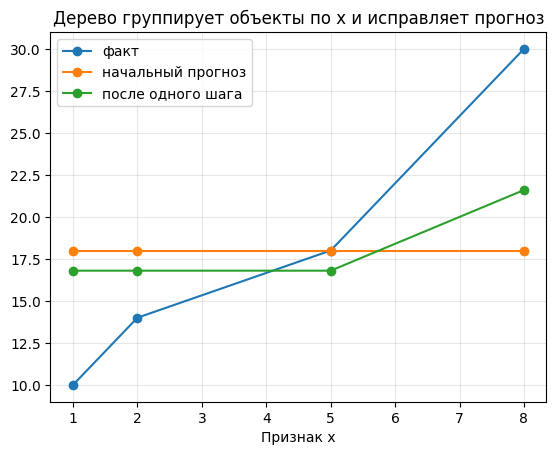

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x_step=np.array([1.,2.,5.,8.]).reshape(-1,1)  # содержательный признак объекта
y=np.array([10.,14.,18.,30.])
pred0=np.full_like(y,y.mean())
residual=y-pred0
from sklearn.tree import DecisionTreeRegressor
correction_tree=DecisionTreeRegressor(max_depth=1,random_state=42).fit(x_step,residual)
correction=correction_tree.predict(x_step)  # приближение остатков по признаку x
learning_rate=.3
pred1=pred0+learning_rate*correction
display(pd.DataFrame({'x':x_step.ravel(),'факт':y,'первый прогноз':pred0,'остаток':residual,'прогноз дерева для остатка':correction,'после шага':pred1}))
plt.plot(x_step,y,marker='o',label='факт'); plt.plot(x_step,pred0,marker='o',label='начальный прогноз'); plt.plot(x_step,pred1,marker='o',label='после одного шага')
plt.xlabel('Признак x'); plt.grid(alpha=.3); plt.legend(); plt.title('Дерево группирует объекты по x и исправляет прогноз'); plt.show()


## 2. Несколько последовательных шагов

После первого исправления остатки считают заново. Второе дерево уже видит меньшие и другие ошибки, поэтому решает новую задачу.

Бустинг — не набор одинаковых деревьев: порядок важен, а каждое дерево зависит от всех предыдущих.


In [ ]:
from IPython.core.interactiveshell import no_op


pred=pred0.copy(); rows=[]
for step in range(3):
 residual=y-pred
 stump=DecisionTreeRegressor(max_depth=1,random_state=step).fit(x_step,residual)
 correction=stump.predict(x_step)
 pred=pred+learning_rate*correction
 rows.append({'шаг':step+1,'MAE':np.mean(np.abs(y-pred))})
pd.DataFrame(rows)


,шаг,MAE
0,1,4.800
1,2,3.960
2,3,2.772


## 3. Почему бустинг «градиентный» *

Для MSE полезное направление совпадает с остатками: остаток показывает, куда нужно сдвинуть прогноз. Для log loss и других функций формула отличается: используют отрицательный градиент функции потерь.

Подробно разбираться в градиентах и производных в рамках этого курса необязателено. Важно: на каждом шаге выбирается направление уменьшения текущей ошибки, а новое дерево приближает это направление.


## 4. Learning rate и число деревьев

Обновление имеет вид $F_m(x)=F_{m-1}(x)+\eta h_m(x)$.

Маленький learning_rate делает шаг осторожнее и обычно требует больше деревьев. Большой учится быстрее, но легче переобучается. Сравнение при фиксированном числе деревьев допустимо как отдельный эксперимент, однако для финального выбора learning_rate и n_estimators настраивают совместно.


## 5. Слабые деревья

Базовые деревья обычно неглубокие. Глубина определяет сложность взаимодействий:

- глубина 1 — одно условие;
- глубина 2 может описывать два последовательных условия, иногда по одному и тому же признаку;
- глубокие деревья делают ансамбль гибким и более склонным к переобучению.

Бустинг превращает множество простых правил в сложную функцию.

В пп. 1–4 был микро-пример на четырёх точках. Ниже — тот же алгоритм на сквозном синтетическом датасете `make_regression`: данные делим на **train** и **validation** через `train_test_split` (сравнение глубин — только по validation).


In [3]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

X,y=make_regression(n_samples=900,n_features=10,n_informative=6,noise=25,random_state=42)
Xt,Xv,yt,yv=train_test_split(X,y,test_size=.3,random_state=42)
for depth in [1,2,4,7]:
 m=GradientBoostingRegressor(n_estimators=180,learning_rate=.05,max_depth=depth,random_state=42).fit(Xt,yt)
 print('depth',depth,'train MAE',round(mean_absolute_error(yt,m.predict(Xt)),1),'validation MAE',round(mean_absolute_error(yv,m.predict(Xv)),1))


depth 1 train MAE 41.2 validation MAE 48.3
depth 2 train MAE 23.0 validation MAE 35.8
depth 4 train MAE 10.5 validation MAE 33.3
depth 7 train MAE 1.0 validation MAE 43.4


## 6. Функции потерь

Регрессия может оптимизировать квадратичную, абсолютную или Huber-ошибку. Классификация обычно использует log loss.

**Функция потерь** определяет, какие ошибки сильнее влияют на следующую поправку. **Метрика** при этом может быть другой.


## 7. Переобучение по мере добавления деревьев

Train-ошибка обычно продолжает уменьшаться. Validation-ошибка сначала падает, затем может начать расти. Лучшее число деревьев выбирают по validation.

Кривая ниже показывает **post-hoc** выбор: по уже обученной модели смотрят, на какой итерации validation была лучшей. Это ещё не early stopping — в следующем разделе обучение остановят автоматически.


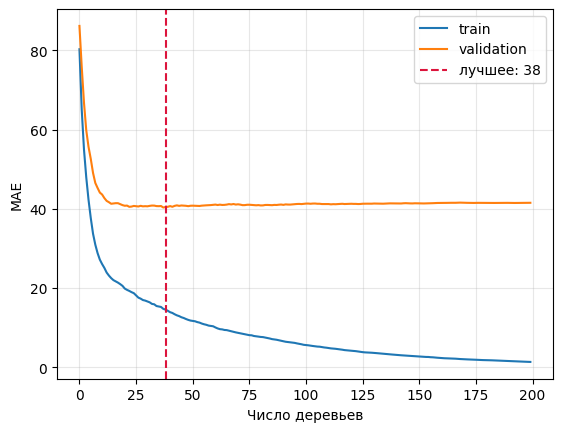

In [18]:
model=GradientBoostingRegressor(n_estimators=200,learning_rate=.5,max_depth=3,random_state=42).fit(Xt,yt)
train_mae=[]; val_mae=[]
for pt,pv in zip(model.staged_predict(Xt),model.staged_predict(Xv)):
 train_mae.append(mean_absolute_error(yt,pt)); val_mae.append(mean_absolute_error(yv,pv))
best=np.argmin(val_mae)+1
plt.plot(train_mae,label='train'); plt.plot(val_mae,label='validation'); plt.axvline(best,color='crimson',ls='--',label=f'лучшее: {best}')
plt.xlabel('Число деревьев'); plt.ylabel('MAE'); plt.grid(alpha=.3); plt.legend(); plt.show()


## 8. Early stopping и post-hoc выбор числа деревьев

**Early stopping** в sklearn откладывает часть train во внутреннюю validation и прекращает обучение, если метрика не улучшается `n_iter_no_change` итераций подряд. Число деревьев можно также подобрать post-hoc (лат. "после этого") по validation-кривой выше — оба способа экономят деревья и снижают переобучение.

Финальную оценку на **test** делают один раз после выбора гиперпараметров по train/validation.


In [19]:
early=GradientBoostingRegressor(
 n_estimators=350,learning_rate=.1,max_depth=3,
 validation_fraction=.2,n_iter_no_change=15,tol=1e-4,random_state=42
).fit(Xt,yt)
print('Лимит деревьев:',350,'— фактически обучено:',early.n_estimators_)


Лимит деревьев: 350 — фактически обучено: 258


## 9. Когда внутренняя validation неверна

Early stopping и post-hoc выбор требуют честной validation: при временных рядах и группах объектов случайный split может завышать качество. Используют разбиение по времени или группам.


## 10. Классификация

Для классификации ансамбль улучшает не классы 0/1 напрямую, а внутренние числовые значения, связанные с вероятностями. Функция потерь обычно log loss.

Как и в логистической регрессии, порог превращает вероятность в класс, а метрику выбирают по цене FP и FN.


## 11. Вероятности классификационного бустинга

Ансамбль сначала формирует внутреннее числовое значение, затем преобразует его в вероятность. Эта вероятность может быть плохо откалибрована.

Порог и калибровку выбирают на validation, как в логистической регрессии.


## 12. Bagging и boosting

| | Random Forest | Gradient Boosting |
|---|---|---|
| Обучение деревьев | независимо | последовательно |
| Главная идея | усреднить разнообразные модели | исправлять текущие ошибки |
| Параллельность | высокая | ограниченная (следующее дерево считается строго ПОСЛЕ предыдущего, но можно параллелить вычисления внутри одного дерева) |
| Настройка | обычно проще | чувствительнее к параметрам |
| Переобучение при числе деревьев | обычно стабилизируется | возможно |

Ни один метод не выигрывает всегда: сравнение проводят одним validation-протоколом.


## 13. Когда лес, а когда бустинг

Лес — сильный устойчивый baseline, проще настраивается и хорошо распараллеливается. Бустинг часто даёт более высокое качество на табличных данных, но требует осторожной настройки.

Сравнение проводят по одинаковому CV, учитывая время обучения и прогноза.


## 14. Нужна ли предобработка для бустинга

Деревьям бустинга обычно не нужно масштабирование. sklearn GradientBoosting ожидает числовые признаки и обработанные пропуски; HistGradientBoosting поддерживает пропуски.


## 15. Обзор реализаций Gradient Boosting *

XGBoost и LightGBM предлагают эффективные реализации; CatBoost особенно удобен для категориальных признаков. Названия параметров и возможности различаются; настройки не переносят между библиотеками без проверки документации.


## 16. Ограничения бустинга

Бустинг чувствителен к гиперпараметрам и изменениям распределения, плохо экстраполирует, хуже распараллеливается, чем лес. При squared error он чувствителен к выбросам цели; существуют устойчивые функции потерь.


## 17. Эксплуатация и мониторинг после внедрения

Вероятности не гарантированно откалиброваны. После внедрения следят за данными, качеством, временем и размером зафиксированной модели.


## 18. Анализ ошибок бустинга

Изучают группы с крупными ошибками. Новый признак должен возникать из гипотезы об этих ошибках и проверяться отдельным validation-экспериментом.


## 19. Importance: impurity vs permutation

Impurity importance имеет ограничения деревьев; для разработки её дополняют permutation importance на validation. Importance объясняет использование признака моделью, но не причинность.


## 20. Чек-лист настройки

1. Зафиксировать split, metric и baseline.
2. Начать с неглубоких деревьев.
3. Совместно подобрать `learning_rate` и `n_estimators`.
4. Следить за validation-кривой и использовать early stopping.
5. Настроить глубину и минимальный размер листа.
6. Анализировать ошибки и устойчивость на CV.
7. Один раз оценить финальный вариант на test.

> **Главная мысль.** Бустинг строит сильную модель последовательностью небольших исправлений; осторожный шаг и честная validation-проверка важнее максимальной сложности.
